In [22]:
import os
import librosa 
import numpy as np
import glob
import librosa
import pandas as pd

### **EDA of the audio files** 

**Names of the audio files:** Author ID, Phrase, Emotion, Intensity of emotion.

**Phrases:** 
* IEO: It's eleven o'clock
* TIE: That is exactly what happened
* IOM: I'm on my way to the meeting
* IWW: I wonder what this is about
* TAI: The airplane is almost full
* MTI: Maybe tomorrow it will be cold
* IWL: I would like a new alarm clock
* ITH: I think I have a doctor's appointment
* DFA: Don't forget a jacket
* ITS: I think I've seen this before
* TSI: The surface is slick
* WSI: We'll stop in a couple of minutes

**Intensity of emotion:**
* LO: Low
* MD: Medium
* HI: High
* XX: Unspecified 

In [16]:
#Audio dataset root directory
DATASET_ROOT = "../AudioWAV"

In [17]:
import IPython.display as ipd
ipd.Audio(os.path.join(DATASET_ROOT, "1001_DFA_ANG_XX.wav"))

## Extraction Data
1. Extraction of the Minimum, Maximum, Averague  duration.
2. Extraction of the number by emotions.
3. Class distribution
4. Visualization of two spectrograms 

In [9]:
import glob

audio_files = glob.glob(os.path.join(DATASET_ROOT, "*.wav"))

durations = []
#Extract durations of all audio files

for audio_file in audio_files:
    try:
        duration = librosa.get_duration(path=audio_file)
        durations.append(duration)
    except Exception as e:
        print(f"Could not process file {os.path.basename(audio_file)}: {e}")

if durations:
    print(f"\nTotal number of audio files processed: {len(durations)}")
    print(f"Minimum duration: {min(durations):.2f} seconds")
    print(f"Maximum duration: {max(durations):.2f} seconds")
    print(f"Average duration: {sum(durations) / len(durations):.2f} seconds")
else:
    print("No audio files found or processed.")


c:\Users\alejo\SEMESTER_2_2026\Maching Learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Total number of audio files processed: 7442
Minimum duration: 1.27 seconds
Maximum duration: 5.00 seconds
Average duration: 2.54 seconds


{'ANG': 1271, 'DIS': 1271, 'FEA': 1271, 'HAP': 1271, 'NEU': 1087, 'SAD': 1271}


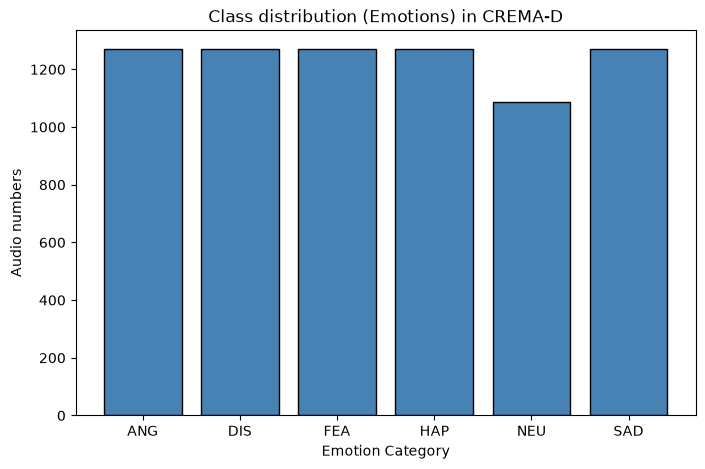

In [18]:
#Extracting the emotion label from the filename and class distribution  
import matplotlib.pyplot as plt
count_emotions = {
    "ANG": 0,
    "DIS": 0,
    "FEA": 0,
    "HAP": 0,
    "NEU": 0,
    "SAD": 0
}
for audio_file in audio_files:
    filename=os.path.basename(audio_file)
    parts= filename.split('_')
    if len(parts) >= 3:
        count_emotions[parts[2]] += 1
        
print(count_emotions)       

#Class distribution
emotions = list(count_emotions.keys())
amounts = list(count_emotions.values())
plt.figure(figsize=(8, 5))
plt.bar(emotions, amounts, color='steelblue', edgecolor='black')

plt.title('Class distribution (Emotions) in CREMA-D')
plt.xlabel('Emotion Category')
plt.ylabel('Audio numbers')

plt.show()

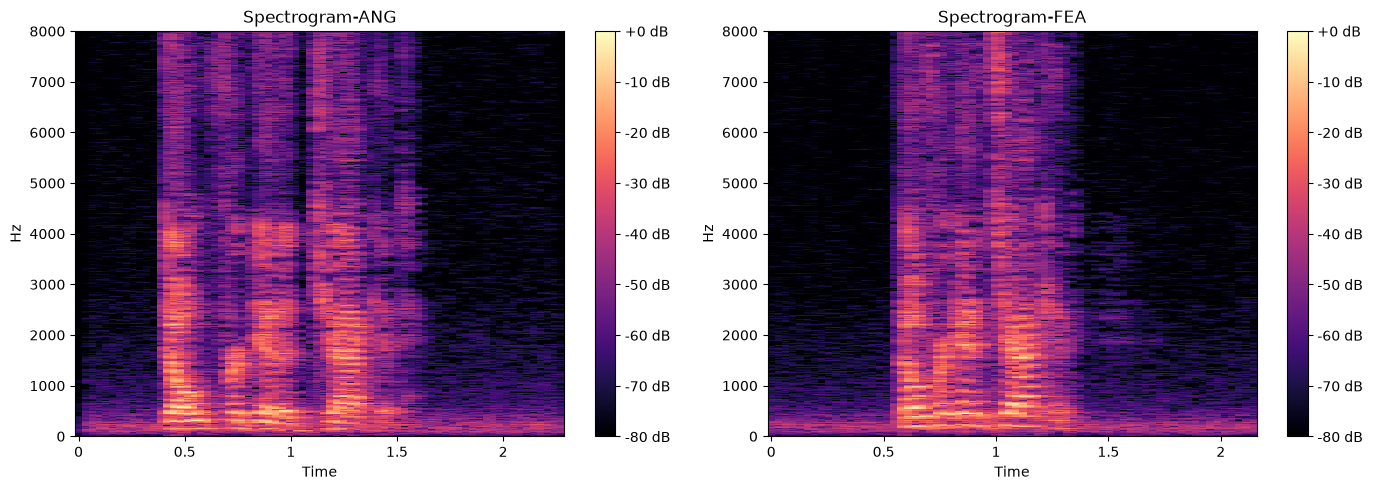

In [19]:
#Visualization of two spectrograms 
wav1, sr = librosa.load(os.path.join(DATASET_ROOT, "1001_DFA_ANG_XX.wav"), sr= None)
wav2, sr = librosa.load(os.path.join(DATASET_ROOT, "1001_DFA_FEA_XX.wav"), sr= None)


spec1 = librosa.amplitude_to_db(np.abs(librosa.stft(wav1)), ref=np.max)
spec2 = librosa.amplitude_to_db(np.abs(librosa.stft(wav2)), ref=np.max)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
img1 =librosa.display.specshow(spec1, y_axis='linear', x_axis= 'time', sr=sr, ax= ax[0])
ax[0].set_title('Spectrogram-ANG')
img2 =librosa.display.specshow(spec2, y_axis='linear', x_axis= 'time', sr=sr, ax= ax[1])
ax[1].set_title('Spectrogram-FEA')

fig.colorbar(img1, ax=ax[0], format="%+2.0f dB")
fig.colorbar(img2, ax=ax[1], format="%+2.0f dB")

plt.tight_layout()
plt.show()

### 

### **Promedio del Audio y ajuste**

In [20]:

# Processing audio files

Target_duration = 3.0  # Target duration in seconds

def pad_or_truncate_audio(file_path, target_duration=Target_duration):
    try:
        wav, sr = librosa.load(file_path, sr=16000)
        
        wav_fixed = librosa.util.fix_length(wav, size = int(target_duration * sr))

        return wav_fixed, sr
    
    except Exception as e:
        print(f"Error processing file {os.path.basename(file_path)}: {e}")
        return None, None 

In [21]:
#test
wav_fixed, sr = pad_or_truncate_audio(os.path.join(DATASET_ROOT, "1001_DFA_ANG_XX.wav"))


print(f"Original duration: {librosa.get_duration(path=os.path.join(DATASET_ROOT, '1001_DFA_ANG_XX.wav')):.2f} seconds")
print(f"Fixed duration: {librosa.get_duration(y=wav_fixed, sr=sr):.2f} seconds")  # Assuming default sampling rate of 22050 Hz

Original duration: 2.28 seconds
Fixed duration: 3.00 seconds


### Data Leakage
Separados 70-15-15 pero por la cantidad de actores del dataset

In [23]:


def extraer_caracteristicas_acusticas(WAV_signal, tasa_muestreo=16000):
    """
    Calcula el promedio temporal de las características acústicas.
    Retorna un diccionario con nombres de variables descriptivos.
    """
    # 1. MFCC 
    matriz_mfcc = librosa.feature.mfcc(y=WAV_signal, sr=tasa_muestreo, n_mfcc=20)
    promedios_mfcc = np.mean(matriz_mfcc.T, axis=0)
    
    # 2. Zero Crossing Rate (Tasa de cruces por cero)
    tasa_cruces_cero = np.mean(librosa.feature.zero_crossing_rate(y=WAV_signal))    
    # 3. Spectral Centroid (Centroide Espectral)
    centroide_espectral = np.mean(librosa.feature.spectral_centroid(y=WAV_signal, sr=tasa_muestreo))
    
    # 4. RMS Energy (Energía de la raíz cuadrada media)
    energia_rms = np.mean(librosa.feature.rms(y=WAV_signal))
    
    # 5. Spectral Rolloff (Frecuencia de corte al 85%)
    rolloff_espectral = np.mean(librosa.feature.spectral_rolloff(y=WAV_signal, sr=tasa_muestreo, roll_percent=0.85))
    
    # 6. Spectral Bandwidth 
    ancho_banda_espectral = np.mean(librosa.feature.spectral_bandwidth(y=WAV_signal, sr=tasa_muestreo))
    
    # Diccionario para almacenar todas las características extraídas
    caracteristicas = {}
    
    # Asignar nombre individual a cada uno de los 20 MFCCs (ej. mfcc_1, mfcc_2...)
    for indice, valor in enumerate(promedios_mfcc, start=1):
        caracteristicas[f'mfcc_{indice}'] = valor
        
    caracteristicas['tasa_cruces_cero'] = tasa_cruces_cero
    caracteristicas['centroide_espectral'] = centroide_espectral
    caracteristicas['energia_rms'] = energia_rms
    caracteristicas['rolloff_espectral'] = rolloff_espectral
    caracteristicas['ancho_banda_espectral'] = ancho_banda_espectral
    
    return caracteristicas


In [24]:
def procesar_dataset_y_crear_dataframe(ruta_dataset, duracion_objetivo=3.0):
    """
    Itera sobre los audios, ajusta su duración y extrae características.
    """
    rutas_archivos_audio = glob.glob(os.path.join(ruta_dataset, "*.wav"))
    lista_datos_completos = []
    total_archivos = len(rutas_archivos_audio)
    
    print(f"Iniciando extracción de características de {total_archivos} archivos...")
    
    for contador, ruta_archivo in enumerate(rutas_archivos_audio, start=1):
        nombre_archivo = os.path.basename(ruta_archivo)
        partes_nombre = nombre_archivo.split('_')
        
        if len(partes_nombre) >= 3:
            id_actor = partes_nombre[0]
            etiqueta_emocion = partes_nombre[2]
            
            # Llamada a la función de truncado
            audio_ajustado, tasa_muestreo = pad_or_truncate_audio(ruta_archivo, duracion_objetivo)
            
            if audio_ajustado is not None:
                # Extraer características acústicas
                datos_fila = extraer_caracteristicas_acusticas(audio_ajustado, tasa_muestreo)
                
                # Agregar identificacion 
                datos_fila['id_actor'] = id_actor
                datos_fila['emocion'] = etiqueta_emocion
                
                lista_datos_completos.append(datos_fila)
        
        # Imprimir progreso cada 500 archivos para saber que el script sigue corriendo
        if contador % 500 == 0:
            print(f"Procesados {contador} de {total_archivos} audios...")
            
    print("¡Extracción completada con éxito!")
    return pd.DataFrame(lista_datos_completos)

In [25]:
df_caracteristicas = procesar_dataset_y_crear_dataframe(DATASET_ROOT)

Iniciando extracción de características de 7442 archivos...
Procesados 500 de 7442 audios...
Procesados 1000 de 7442 audios...
Procesados 1500 de 7442 audios...
Procesados 2000 de 7442 audios...
Procesados 2500 de 7442 audios...
Procesados 3000 de 7442 audios...
Procesados 3500 de 7442 audios...
Procesados 4000 de 7442 audios...
Procesados 4500 de 7442 audios...
Procesados 5000 de 7442 audios...
Procesados 5500 de 7442 audios...
Procesados 6000 de 7442 audios...
Procesados 6500 de 7442 audios...
Procesados 7000 de 7442 audios...
¡Extracción completada con éxito!


In [26]:
from sklearn.model_selection import GroupShuffleSplit

# 1. Separar variables predictoras (X), variable objetivo (y) y la variable de agrupación
X = df_caracteristicas.drop(columns=['id_actor', 'emocion'])
y = df_caracteristicas['emocion']
grupos_actores = df_caracteristicas['id_actor']

# 2. Primera división: Separar Train (70%) y un conjunto Temporal (Val + Test) (30%)
gss_temp = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)

for train_idx, temp_idx in gss_temp.split(X, y, groups=grupos_actores):
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]
    actores_train = grupos_actores.iloc[train_idx]
    
    X_temp = X.iloc[temp_idx]
    y_temp = y.iloc[temp_idx]
    actores_temp = grupos_actores.iloc[temp_idx]

# 3. Segunda división: Dividir el conjunto Temporal a la mitad para Validation (15%) y Test (15%)
# test_size=0.5 significa el 50% de los actores que quedaron en 'actores_temp'
gss_val_test = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)

for val_idx, test_idx in gss_val_test.split(X_temp, y_temp, groups=actores_temp):
    X_val = X_temp.iloc[val_idx]
    y_val = y_temp.iloc[val_idx]
    actores_val = actores_temp.iloc[val_idx]
    
    X_test = X_temp.iloc[test_idx]
    y_test = y_temp.iloc[test_idx]
    actores_test = actores_temp.iloc[test_idx]

# 4. Comprobación de la prevención de Data Leakage (speaker-disjoint)
set_train = set(actores_train)
set_val = set(actores_val)
set_test = set(actores_test)

# Verificar explícitamente que las intersecciones estén vacías
intersec_train_val = set_train.intersection(set_val)
intersec_train_test = set_train.intersection(set_test)
intersec_val_test = set_val.intersection(set_test)

# 5. Imprimir resultados y validaciones
print(f"Audios en Entrenamiento: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Audios en Validación: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Audios en Prueba: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)\n")

print(f"Actores únicos en Train ({len(set_train)}): {list(set_train)[:5]}...")
print(f"Actores únicos en Val ({len(set_val)}): {list(set_val)[:5]}...")
print(f"Actores únicos en Test ({len(set_test)}): {list(set_test)[:5]}...\n")

print("Verificación de Fuga de Datos (Speaker-Disjoint):")
print(f"Train vs Val: {intersec_train_val} (Libre de fugas: {len(intersec_train_val) == 0})")
print(f"Train vs Test: {intersec_train_test} (Libre de fugas: {len(intersec_train_test) == 0})")
print(f"Val vs Test: {intersec_val_test} (Libre de fugas: {len(intersec_val_test) == 0})")

Audios en Entrenamiento: 5152 (69.2%)
Audios en Validación: 1142 (15.3%)
Audios en Prueba: 1148 (15.4%)

Actores únicos en Train (63): ['1085', '1032', '1025', '1049', '1052']...
Actores únicos en Val (14): ['1063', '1011', '1012', '1041', '1066']...
Actores únicos en Test (14): ['1078', '1067', '1045', '1016', '1013']...

Verificación de Fuga de Datos (Speaker-Disjoint):
Train vs Val: set() (Libre de fugas: True)
Train vs Test: set() (Libre de fugas: True)
Val vs Test: set() (Libre de fugas: True)


## Modelos 

### Modelo 1 

### Modelo 2

### Modelo 3  


### Modelo 4

### Modelo 5